# **2024 WKF Male Kata: An Analysis**

Gordon Jay Chan  
December 2024

## **Table of Contents**

1. Introduction
    - 1a. Background
    - 1b. Data Collection
2. Dataset
    - 2a. Renaming Data & Adding Kata Tiers
    - 2b. Overview
    - 2c. Clarifications
3. Kata
    - 3a. Master Kata Table
    - 3b. Kata Tiers
    - 3c. Popularity
    - 3d. Average Score
    - 3e. Win Rate
    - 3f. Insights
4. Karateka
    - 4a. Average Score
    - 4b. Win Rate
    - 4c. Insights
5. Tournaments
    - 5a. Unique Karateka, Unique Kata, and Average Score
    - 5b. Insights
6. Do Less Common Kata Perform Better?
    

## **1. Introduction**

### 1a. Background
At karate competitions, karate athletes (karateka) compete in either kata (forms) or kumite (sparring). A Kata is a series of predetermined movements that is meant to be performed with perfect technique. 

The World Karate Federation (WKF) is the largest sport karate governing body, and their top-level events (other than Karate World Championships, which weren't held in 2024) are called Karate 1 Premier League tournaments. In 2024, there were four of these events: Paris, Antalya, Cairo, and Casablanca. This analysis explores the 426 male kata performances from the four 2024 K1 Premier tournaments. 

Kata competitors choose 5 kata to perform at a given event (each round, a karateka must perform a different kata, but if they perform more than 5 times at one tournament, they may repeat a kata for their sixth match), and they have 102 WKF-approved kata to choose from. The kata are split into tiers of "Beginner," "Intermediate," and "Advanced," with advanced kata being the most common for top-level karateka to perform, naturally. Strategic kata selection significantly impacts competition success, and as a male kata competitor myself, I aim to examine top-level karate competition data in order to uncover insights influencing success in male kata competition.

### 1b. Data Collection
I compiled the dataset from sportdata.org's [events archive](https://www.sportdata.org/wkf/set-online/calendar_archiv_main.php?active_menu=calendar#center_outer_middle). Each row in the dataset represents a single kata performance, detailing the kata performed, total judge score, average judge score, round, whether the karateka won their match, and which event the performance took place at.  
<br>

## **2. Dataset**

### 2a. Renaming Data & Adding Kata Tiers
Here, I add a column to my dataset that states the tier of kata (beginner, intermediate, or advanced) being performed.
I used the [USA Karate Official Kata List](https://assets.contentstack.io/v3/assets/blteb7d012fc7ebef7f/blt948731043d7aeb6c/64887a8bea50bc52adbe8b23/2023-03-14_Official_Kata_List.PDF) to define my kata tiers.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

In [10]:
df = pd.read_csv("2024 Kata Data.csv")

df = df.replace("Chatanyara", "Chatanyara Kusanku")
df = df.replace("Chibana Kusanku", "Chibana No Kusanku")

In [11]:
adv_kata = ['Anan', 'Anan Dai', 'Chatanyara Kusanku', 'Chibana No Kusanku', 'Chinto', 'Gankaku', 'Gojushiho', 'Gojushiho Dai', 'Gojushiho Sho', 'Hakucho', 
           'Heiku', 'Kanchin', 'Kanku Sho', 'Kishimoto No Kushanku', 'Kousoukun Dai', 'Kururunfa', 'Kyan No Chinto', 'Kyan No Wanshu',
           'Matsumura Bassai', 'Nipaipo', 'Ohan', 'Ohan Dai', 'Oyadomari No Passai', 'Paiku', 'Papuren', 'Sansai', 'Seishan', 'Suparinpei',
           'Tomari Bassai', 'Unsu', 'Useishi']
interm_kata = ['Ananko', 'Aoyagi', 'Bassai', 'Bassai Dai', 'Bassai Sho', 'Chinte', 'Enpi', 'Garyu', 'Hangetsu', 'Haufa', 'Ishimine Bassai',
              'Itosu Rohai Shodan', 'Itosu Rohai Nidan', 'Itosu Rohai Sandan', 'Jiin', 'Jion', 'Jitte', 'Juroku', 'Kanku Dai', 'Kanshu', 'Kousoukun',
              'Kousoukun Sho', 'Kusanku', 'Matsukaze', 'Matsumura Rohai', 'Meikyo', 'Myojo', 'Naifanchin Shodan', 'Naifanchin Nidan',
              'Naifanchin Sandan', 'Naihanchi', 'Nijushiho', 'Niseishi', 'Pachu', 'Passai', 'Rohai', 'Saifa', 'Sanchin', 'Sanseiru', 'Sanseru',
              'Seichin', 'Seienchin', 'Seipai', 'Seiryu', 'Seisan', 'Shiho Kousoukun', 'Shinpa', 'Shinsei', 'Shisochin', 'Sochin', 'Tekki Shodan',
              'Tekki Nidan', 'Tekki Sandan', 'Tensho', 'Wankan', 'Wanshu']

def assign_tier(kata):
    if kata in adv_kata:
        return 'Advanced'
    elif kata in interm_kata:
        return 'Intermediate'
    else:
        return 'Beginner'

df['Kata Tier'] = df['Kata'].apply(assign_tier)

### 2b. Overview

In [13]:
df.head()

#The Top 5 lines of the dataset, just so you can see it.

,Kata,Score,Avg Score,Won?,Karateka,Round #,Tournament,Kata Tier
0,Papuren,40.7,8.14,False,Jefferson Ortiz,rr,Paris,Advanced
1,Gojushiho Sho,42.4,8.48,True,Enes Ozdemir,rr,Paris,Advanced
2,Ohan,43.5,8.70,True,Sakichi Abe,rr,Paris,Advanced
3,Papuren,38.6,7.72,False,Dyun Kimura,rr,Paris,Advanced
4,Unsu,42.8,8.56,True,Enes Ozdemir,rr,Paris,Advanced


In [14]:
df.shape

#The dimensions of the dataset.

(426, 8)

In [15]:
num_unique_kata = df["Kata"].nunique()
num_unique_karateka = df["Karateka"].nunique()
num_unique_tournament = df["Tournament"].nunique()
min_value = df["Avg Score"].min()
max_value = df["Avg Score"].max()
tier_counts = df['Kata Tier'].value_counts()

display(Markdown("#### Number of unique kata: " + str(num_unique_kata)))
display(Markdown("#### Number of unique karateka: " + str(num_unique_karateka)))
display(Markdown("#### Range of kata scores: " + str(min_value) + " to " + str(max_value)))
display(Markdown("#### Number of tournaments analyzed: " + str(num_unique_tournament)))

#### Number of unique kata: 26

#### Number of unique karateka: 54

#### Range of kata scores: 7.32 to 9.14

#### Number of tournaments analyzed: 4

### 2c. Clarifications
1. The WKF Official Kata List lists "Unsu" and "Unshu" as different kata, but I combined them under the name "Unsu" for this analysis since they're the same kata, just in different styles.  
2. There are seven judges per performance. They each give a score from 5.0 to 10.0, and the highest and lowest scores are disregarded, except in the case of a tie. In the case of a tie, the lowest score is added to the total. If there is still a tie, then the highest score is added to the total.
3. Average score is total score divided by five (the five judges).
4. Karateka first compete in a round-robin pool of four people. There are 8 pools. Then, the winner of each pool is placed into a single-elimination bracket, which is composed of 3 rounds. Finally, four karateka eliminated in the bracket compete in two separate one versus one matches in the repechage pool. Thus, the "Round #" column has values of: rr (round robin), r1 (round 1 of bracket), r2, r3, and rpc (repechage).
<br>
<br>

## **3. Kata Stats**

### 3a. Kata Tiers

In [19]:
display(Markdown("#### Number of advanced kata: " + str(len(adv_kata))))
display(Markdown("#### Number of advanced kata performances: " + str(tier_counts.get('Advanced', 0))))
display(Markdown("#### Number of intermediate kata: " + str(len(interm_kata))))
display(Markdown("#### Number of intermediate kata performances: " + str(tier_counts.get('Intermediate', 0))))

#### Number of advanced kata: 31

#### Number of advanced kata performances: 386

#### Number of intermediate kata: 56

#### Number of intermediate kata performances: 40

In [20]:
performed_advanced_kata = df[df['Kata Tier'] == 'Advanced']['Kata'].unique()

performed_advanced_kata = list(performed_advanced_kata)
unperformed_advanced_kata = [kata for kata in adv_kata if kata not in performed_advanced_kata]

print("Performed Advanced Kata:")
for i, kata in enumerate(performed_advanced_kata, 1):
    print(f"{i}. {kata}")

print("\nUnperformed Advanced Kata:")
for i, kata in enumerate(unperformed_advanced_kata, 1):
    print(f"{i}. {kata}")

Performed Advanced Kata:
1. Papuren
2. Gojushiho Sho
3. Ohan
4. Unsu
5. Ohan Dai
6. Anan Dai
7. Gojushiho Dai
8. Anan
9. Chatanyara Kusanku
10. Kururunfa
11. Suparinpei
12. Chibana No Kusanku
13. Gankaku
14. Kanku Sho
15. Kyan No Chinto
16. Sansai
17. Paiku
18. Nipaipo

Unperformed Advanced Kata:
1. Chinto
2. Gojushiho
3. Hakucho
4. Heiku
5. Kanchin
6. Kishimoto No Kushanku
7. Kousoukun Dai
8. Kyan No Wanshu
9. Matsumura Bassai
10. Oyadomari No Passai
11. Seishan
12. Tomari Bassai
13. Useishi


In [21]:
performed_intermediate_kata = df[df['Kata Tier'] == 'Intermediate']['Kata'].unique()

performed_intermediate_kata = list(performed_intermediate_kata)
unperformed_intermediate_kata = [kata for kata in interm_kata if kata not in performed_intermediate_kata]

print("Performed Intermediate Kata:")
for i, kata in enumerate(performed_intermediate_kata, 1):
    print(f"{i}. {kata}")

print("\nUnperformed Intermediate Kata:")
for i, kata in enumerate(unperformed_intermediate_kata, 1):
    print(f"{i}. {kata}")

Performed Intermediate Kata:
1. Enpi
2. Sochin
3. Pachu
4. Shisochin
5. Jitte
6. Seipai
7. Nijushiho
8. Seisan

Unperformed Intermediate Kata:
1. Ananko
2. Aoyagi
3. Bassai
4. Bassai Dai
5. Bassai Sho
6. Chinte
7. Garyu
8. Hangetsu
9. Haufa
10. Ishimine Bassai
11. Itosu Rohai Shodan
12. Itosu Rohai Nidan
13. Itosu Rohai Sandan
14. Jiin
15. Jion
16. Juroku
17. Kanku Dai
18. Kanshu
19. Kousoukun
20. Kousoukun Sho
21. Kusanku
22. Matsukaze
23. Matsumura Rohai
24. Meikyo
25. Myojo
26. Naifanchin Shodan
27. Naifanchin Nidan
28. Naifanchin Sandan
29. Naihanchi
30. Niseishi
31. Passai
32. Rohai
33. Saifa
34. Sanchin
35. Sanseiru
36. Sanseru
37. Seichin
38. Seienchin
39. Seiryu
40. Shiho Kousoukun
41. Shinpa
42. Shinsei
43. Tekki Shodan
44. Tekki Nidan
45. Tekki Sandan
46. Tensho
47. Wankan
48. Wanshu


### 3b. Master Kata Table

In [23]:
# Step 1: Count the number of performances for each kata
kata_performance_counts = df['Kata'].value_counts().reset_index()
kata_performance_counts.columns = ['Kata', 'Performances']

# Step 2: Calculate the average score for each kata
kata_avg_scores = df.groupby('Kata')['Avg Score'].mean().reset_index()
kata_avg_scores.columns = ['Kata', 'Average Score']
kata_avg_scores['Average Score'] = kata_avg_scores['Average Score'].round(3)  # Round to 3 decimal places

# Step 3: Calculate the win rate for each kata
kata_win_rates = df.groupby('Kata')['Won?'].mean().reset_index()
kata_win_rates.columns = ['Kata', 'Win Rate (%)']
kata_win_rates['Win Rate (%)'] = (kata_win_rates['Win Rate (%)'] * 100).round(2)  # Convert to percentage and round to 2 decimal places

# Step 4: Extract the kata tier
kata_tier = df[['Kata', 'Kata Tier']].drop_duplicates()

# Step 5: Merge all dataframes
kata_analysis = pd.merge(kata_performance_counts, kata_avg_scores, on='Kata')
kata_analysis = pd.merge(kata_analysis, kata_win_rates, on='Kata')
kata_analysis = pd.merge(kata_analysis, kata_tier, on='Kata')

# Step 6: Sort the dataframe by kata names alphabetically
kata_analysis = kata_analysis.sort_values(by='Kata').reset_index(drop=True)

# Step 7: Adjust row indices to start from 1
kata_analysis.index = kata_analysis.index + 1

# Display the final dataframe
display(kata_analysis)

,Kata,Performances,Average Score,Win Rate (%),Kata Tier
1,Anan,24,8.257,62.50,Advanced
2,Anan Dai,32,8.189,37.50,Advanced
3,Chatanyara Kusanku,10,8.264,60.00,Advanced
4,Chibana No Kusanku,13,8.329,38.46,Advanced
5,Enpi,6,8.223,83.33,Intermediate
6,Gankaku,8,8.260,0.00,Advanced
7,Gojushiho Dai,33,8.211,54.55,Advanced
8,Gojushiho Sho,51,8.149,56.86,Advanced
9,Jitte,4,8.435,50.00,Intermediate
10,Kanku Sho,27,8.046,29.63,Advanced


### 3c. Popularity

In [25]:
kata_counts = df['Kata'].value_counts().reset_index()

kata_counts_reset = kata_counts.reset_index(drop = True)
kata_counts_reset.index = kata_counts_reset.index + 1

kata_counts_reset = kata_counts_reset.rename(columns={"count": "Count"})

display(Markdown("#### All Kata Sorted by Popularity"))
display(kata_counts_reset)

#### All Kata Sorted by Popularity

,Kata,Count
1,Unsu,54
2,Gojushiho Sho,51
3,Ohan Dai,38
4,Gojushiho Dai,33
5,Anan Dai,32
6,Suparinpei,32
7,Papuren,27
8,Kanku Sho,27
9,Anan,24
10,Sochin,19


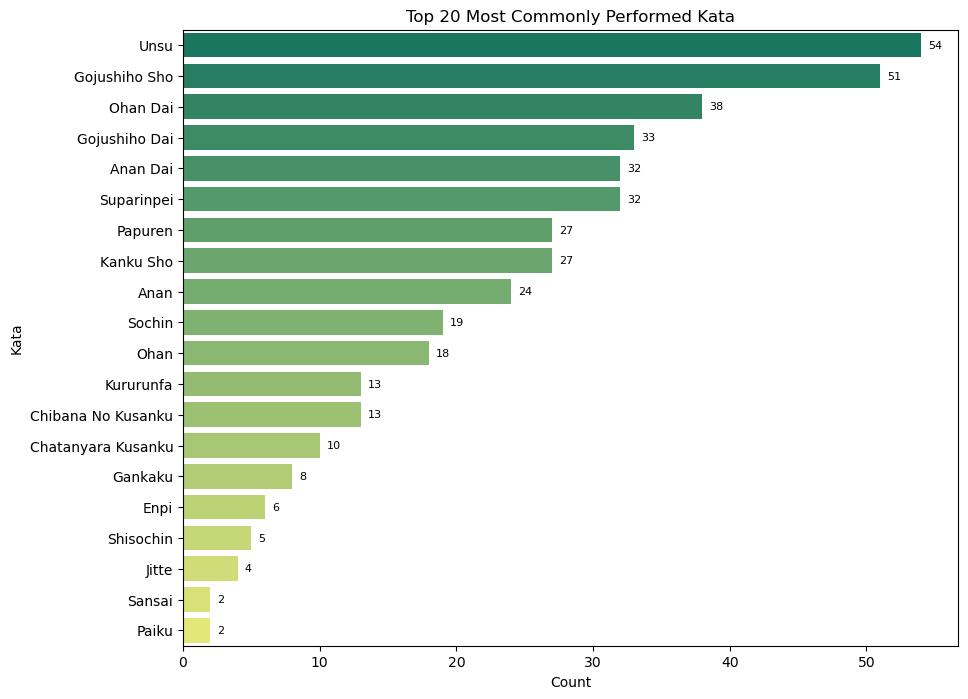

In [26]:
# Reset the index of the Series to convert it to a DataFrame
most_common_kata = kata_counts.head(20).reset_index()

# Plot the bar chart
plt.figure(figsize = (10, 8))
plot = sns.barplot(x = 'count', y = 'Kata', data=most_common_kata, hue = 'Kata', palette='summer')

# Add annotations for the counts
for i, count in enumerate(most_common_kata['count']):
    plot.text(count + 0.5, i, str(count), va='center', fontsize=8)

# Add labels and title
plt.xlabel("Count")
plt.ylabel("Kata")
plt.title("Top 20 Most Commonly Performed Kata")
plt.show()

### 3d. Average Score

In [28]:
# Group by 'Kata' and calculate the average score and the count of performances
kata_stats = df.groupby("Kata").agg(
    Avg_Score = ("Score", "mean"),  
    Count = ("Score", "size") 
).reset_index()

kata_stats["Avg_Score"] = (kata_stats["Avg_Score"] / 5).round(3)

kata_by_avg_score = kata_stats.sort_values(by = "Avg_Score", ascending = False)

kata_by_avg_score_reset = kata_by_avg_score.reset_index(drop = True)
kata_by_avg_score_reset.index = kata_by_avg_score_reset.index + 1

display(Markdown("#### All Kata Sorted by Average Score"))
display(kata_by_avg_score_reset)

#### All Kata Sorted by Average Score

,Kata,Avg_Score,Count
1,Seisan,8.520,2
2,Jitte,8.435,4
3,Shisochin,8.420,5
4,Pachu,8.420,1
5,Chibana No Kusanku,8.329,13
6,Sochin,8.307,19
7,Chatanyara Kusanku,8.264,10
8,Gankaku,8.260,8
9,Anan,8.257,24
10,Suparinpei,8.252,32


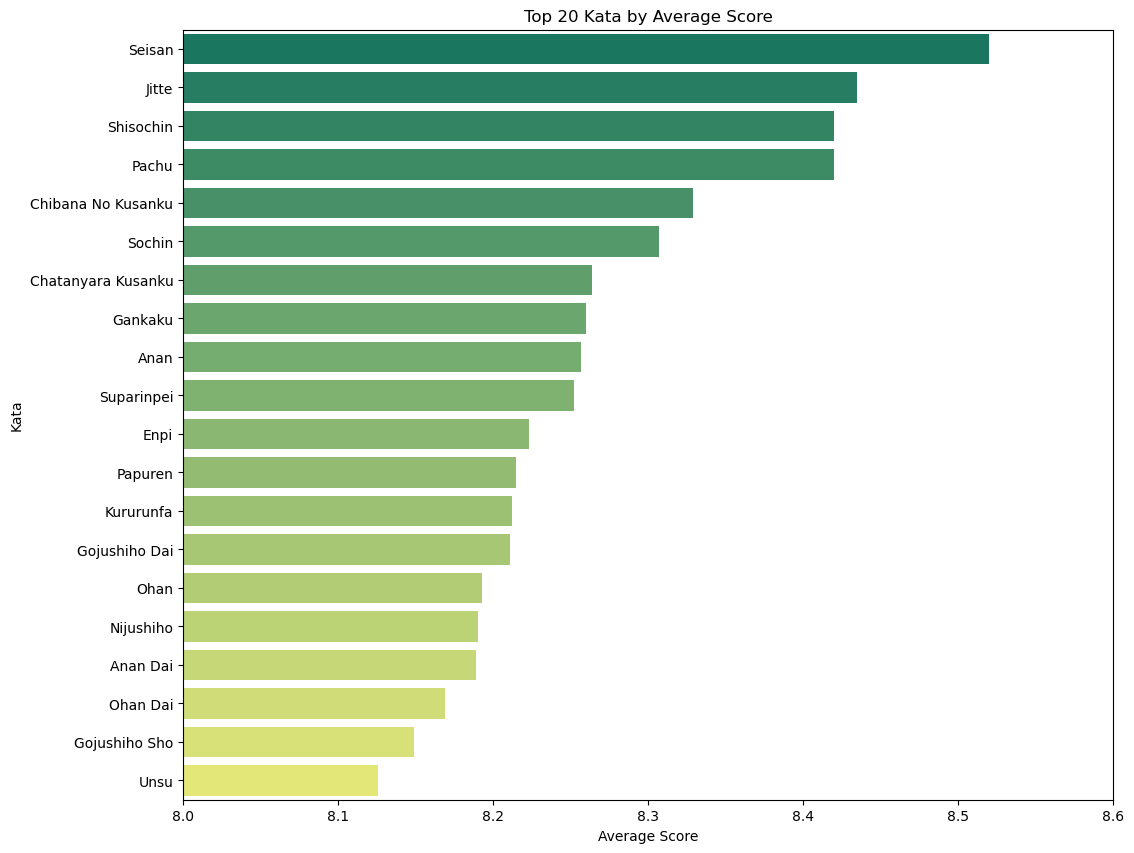

In [29]:
top_kata_by_score = kata_stats.sort_values(by = "Avg_Score", ascending = False).head(20)

plt.figure(figsize = (12, 10))
sns.barplot(data = top_kata_by_score, x = "Avg_Score", y = "Kata", hue = "Kata", palette = "summer")

plt.xlim(8, 8.6)

plt.xlabel("Average Score")
plt.ylabel("Kata")
plt.title("Top 20 Kata by Average Score")
plt.show()

### 3e. Win Rate

In [31]:
# Group by "Kata" and calculate the win percentage and the count of performances
kata_win_stats = df.groupby("Kata").agg(Win_Rate=("Won?", "mean"), Count=("Won?", "size")).reset_index()

kata_win_stats["Win_Rate"] = (kata_win_stats["Win_Rate"] * 100).round(2)
top_kata_win_percentage = kata_win_stats.sort_values(by = "Win_Rate", ascending = False)

top_kata_win_percentage_reset = top_kata_win_percentage.reset_index(drop = True)
top_kata_win_percentage_reset.index = top_kata_win_percentage_reset.index + 1

display(Markdown("#### All Kata Sorted by Win Rate"))
display(top_kata_win_percentage_reset)

#### All Kata Sorted by Win Rate

,Kata,Win_Rate,Count
1,Pachu,100.00,1
2,Shisochin,100.00,5
3,Seisan,100.00,2
4,Nijushiho,100.00,2
5,Enpi,83.33,6
6,Ohan,77.78,18
7,Kururunfa,69.23,13
8,Sochin,63.16,19
9,Anan,62.50,24
10,Suparinpei,62.50,32


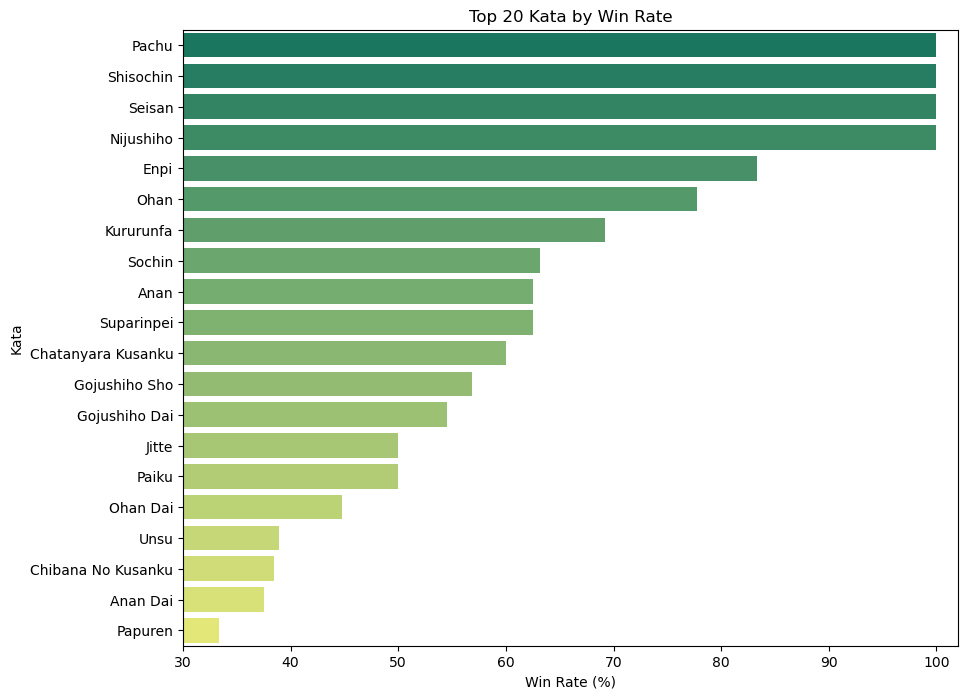

In [32]:
top_15_kata_win_percentage_reset = kata_win_stats.sort_values(by = "Win_Rate", ascending = False).head(20)

plt.figure(figsize = (10, 8))
sns.barplot(data = top_15_kata_win_percentage_reset, x = "Win_Rate", y = "Kata", hue = "Kata", palette = "summer")

plt.xlabel("Win Rate (%)")
plt.ylabel("Kata")
plt.title("Top 20 Kata by Win Rate")
plt.xlim(30, 102)

plt.show()

### 3f. Insights
1. Of the 26 kata performed, 18 are advanced and 8 are intermediate.
2. 18 of the 31 advanced kata were performed. 8 out of the 56 intermediate kata were performed. 
3. The most common kata, in order, are Unsu, Gojushiho Sho, Ohan Dai, Gojushiho Dai, Anan Dai, Suparinpei, Papuren, Kanku Sho, Anan, and Sochin.
4. The kata with the highest average score are Seisan, Jitte, Shisochin, Pachu, Chibana Kusanku, Sochin, Chatanyara Kusanku, Gankaku, Anan, and Suparinpei. However, the top 4 kata's high average scores might be related to the fact that they all have 5 or less performances.
5. The kata with the highest win rates are Pachu, Shisochin, Seisan, Nijushiho, Enpi, Ohan, Kururunfa, Sochin, Anan, and Suparinpei. The top 5 of these kata have significantly less performances than the lower 5.
<br>
<br>

## **4. Karateka Stats**

### 4a. Average Score

In [36]:
# Group by 'Karateka' and calculate the average score and count of performances
karateka_stats = df.groupby('Karateka').agg(
    Avg_Score=('Score', 'mean'),  
    Count=('Score', 'size')  
).reset_index()

karateka_stats['Avg_Score'] = (karateka_stats['Avg_Score'] / 5).round(3)
karateka_stats_sorted = karateka_stats.sort_values(by='Avg_Score', ascending=False)

karateka_stats_sorted_reset = karateka_stats_sorted.reset_index(drop=True)
karateka_stats_sorted_reset.index = karateka_stats_sorted_reset.index + 1

karateka_stats_sorted_reset = karateka_stats_sorted_reset.rename(
    columns={'Karateka': 'Name', 'Avg_Score': 'Avg Score', 'Count': '# of Matches'})

display(Markdown("#### All Karateka Sorted by Average Score"))
display(karateka_stats_sorted_reset)

#### All Karateka Sorted by Average Score

,Name,Avg Score,# of Matches
1,Kakeru Nishiyama,8.684,22
2,Sakichi Abe,8.537,19
3,Ariel Torres,8.495,20
4,Damian Quintero,8.487,3
5,Kazumasa Moto,8.484,19
6,Ali Sofuoglu,8.473,17
7,Enes Ozdemir,8.425,16
8,Ryuji Moto,8.421,21
9,Aoi Funada,8.376,9
10,Yasuhiro Machida,8.371,7


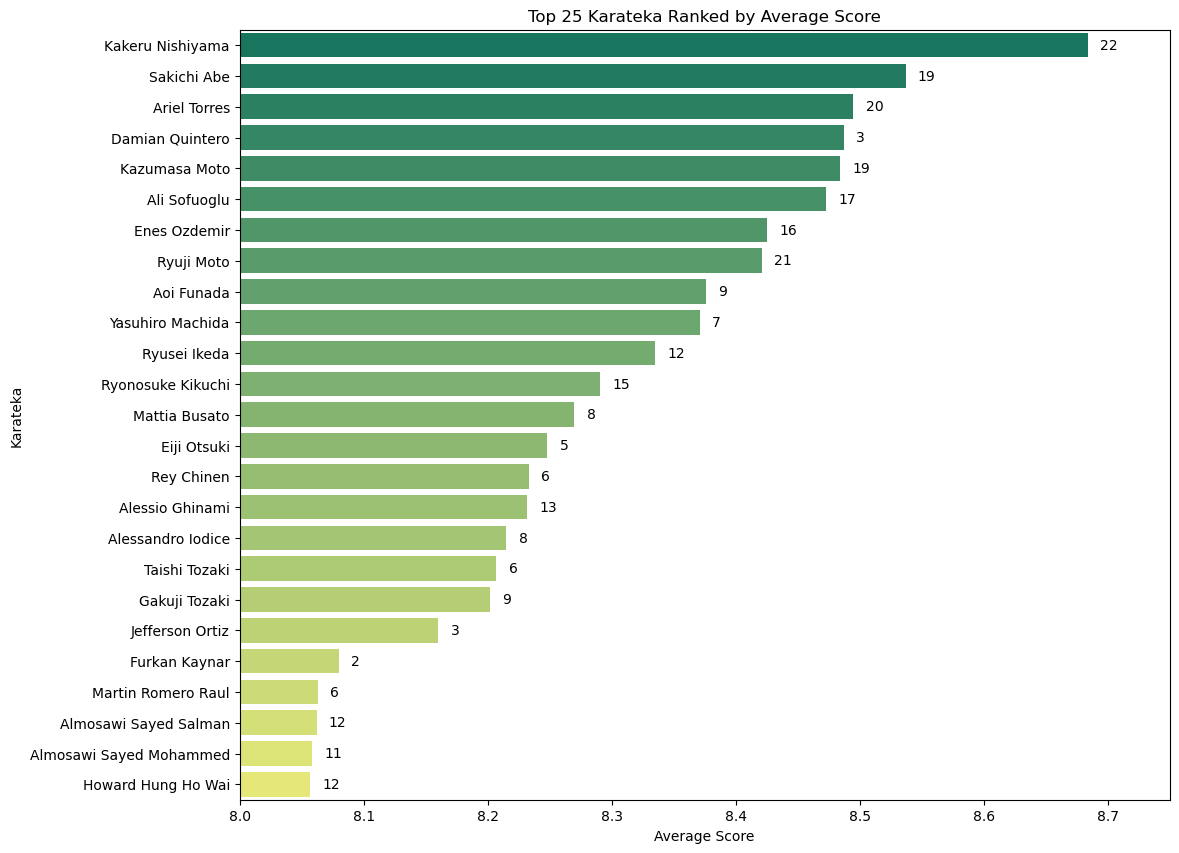

In [37]:
top_25_karateka = karateka_stats_sorted_reset.head(25)

plt.figure(figsize=(12, 10))
sns.barplot(data=top_25_karateka, x = 'Avg Score', y = 'Name', hue = 'Name', palette = 'summer')

plt.xlabel('Average Score')
plt.ylabel('Karateka')
plt.title('Top 25 Karateka Ranked by Average Score')

# Annotate the count of performances
for index, row in top_25_karateka.iterrows():
    plt.text(row['Avg Score'] + .01, index - 1, f"{row['# of Matches']}", va='center')

plt.xlim(8, 8.75)
plt.show()

### 4b. Win Rate

In [39]:
# Group by 'Karateka' and calculate win rate and performance count
karateka_win_stats = df.groupby('Karateka').agg(Win_Rate = ('Won?', 'mean'), Performances = ('Won?', 'size')).reset_index()

karateka_win_stats['Win_Rate'] = (karateka_win_stats['Win_Rate'] * 100).round(2)

karateka_win_stats_sorted = karateka_win_stats.sort_values(by='Win_Rate', ascending=False)

karateka_win_stats_sorted = karateka_win_stats_sorted.reset_index(drop=True)
karateka_win_stats_sorted.index = karateka_win_stats_sorted.index + 1

karateka_win_stats_sorted = karateka_win_stats_sorted.rename(
    columns={'Karateka': 'Name', 'Win_Rate': 'Win Rate (%)', 'Performances': '# of Matches'})

display(Markdown("#### All Karateka Sorted by Win Rate"))
display(karateka_win_stats_sorted)

#### All Karateka Sorted by Win Rate

,Name,Win Rate (%),# of Matches
1,Kakeru Nishiyama,100.00,22
2,Ariel Torres,80.00,20
3,Aoi Funada,77.78,9
4,Ali Sofuoglu,76.47,17
5,Sakichi Abe,73.68,19
6,Kazumasa Moto,73.68,19
7,Ryuji Moto,71.43,21
8,Yasuhiro Machida,71.43,7
9,Enes Ozdemir,68.75,16
10,Rey Chinen,66.67,6


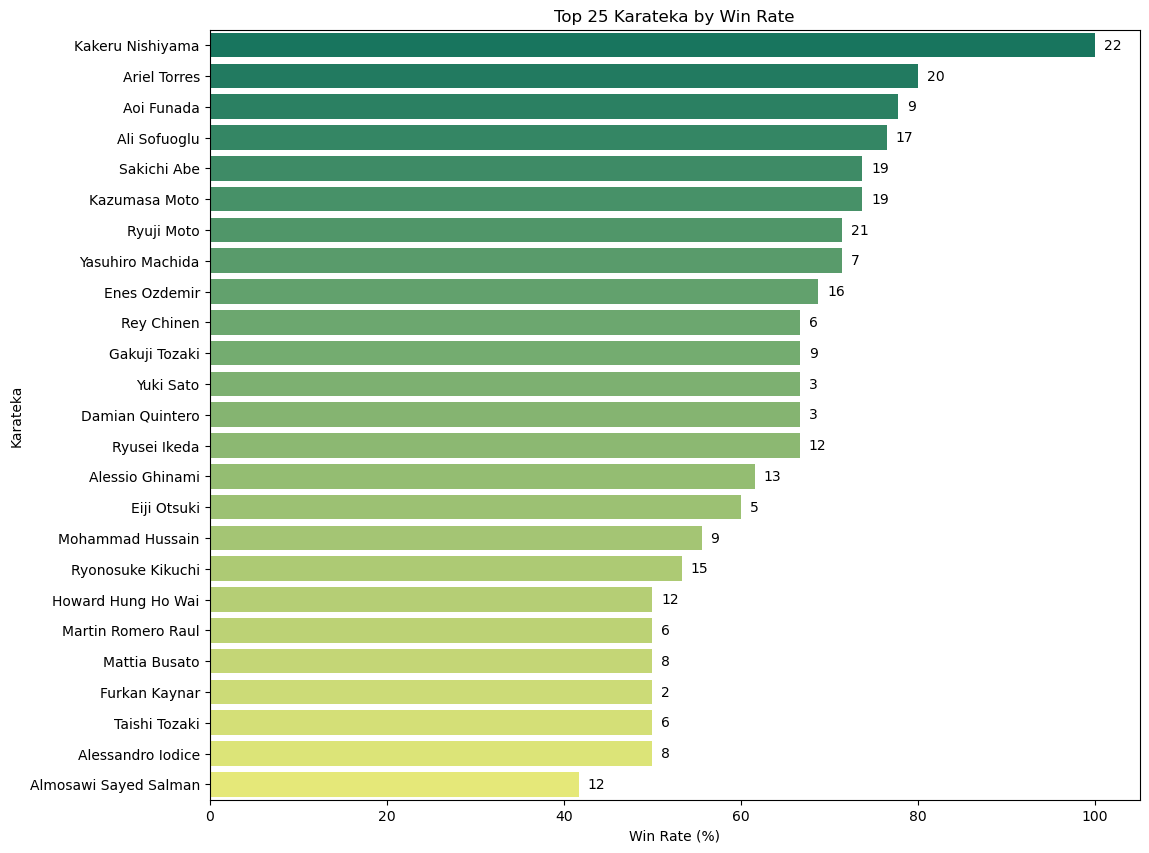

In [40]:
top_25_karateka = karateka_win_stats_sorted.head(25)

plt.figure(figsize=(12, 10))
sns.barplot(data=top_25_karateka, x='Win Rate (%)', y='Name', hue = 'Name', palette='summer')

plt.xlabel('Win Rate (%)')
plt.ylabel('Karateka')
plt.title('Top 25 Karateka by Win Rate')

for index, row in top_25_karateka.iterrows():
    plt.text(row['Win Rate (%)'] + 1, index - 1, f"{row['# of Matches']}", va='center')

plt.show()

### 4c. Insights
1. The karateka with the highest average scores are Kakeru Nishiyama, Sakichi Abe, Ariel Torres, Damian Quintero, and Kazumasa Moto.
2. The karateka with the highest win rates are Kakeru Nishiyama, Ariel Torres, Aoi Funada, Ali Sofuoglu, and Sakichi Abe.
3. Kakeru Nishiyama's average score is incredibly impressive because the difference between his average score and the second place average score is greater than the difference between the second place and eighth place. Additionally, Nishiyama performed his kata more than any other karateka, so his outstanding average score is no fluke. He had such a high number of performances because he never lost a round, so he was never eliminated early.
<br>
<br>

## **5. Tournament Stats**

### 5a. Unique Karateka, Unique Kata, and Average Score

In [44]:
# Group by 'Tournament' and count unique 'Karateka' and 'Kata'
tournament_stats = df.groupby('Tournament').agg(
    Unique_Karateka=('Karateka', 'nunique'), 
    Unique_Kata=('Kata', 'nunique')  
).reset_index()

tournament_stats.index = tournament_stats.index + 1

display(tournament_stats)

,Tournament,Unique_Karateka,Unique_Kata
1,Antalya,28,20
2,Cairo,31,23
3,Casablanca,32,20
4,Paris,32,20


In [45]:
# Group by 'Tournament' and calculate the mean of 'Avg Score'
avg_score_by_tournament = df.groupby('Tournament')['Avg Score'].mean().reset_index()

# Round the average scores to two decimal places for readability
avg_score_by_tournament['Avg Score'] = avg_score_by_tournament['Avg Score'].round(3)

avg_score_by_tournament = avg_score_by_tournament.reset_index(drop=True)
avg_score_by_tournament.index = avg_score_by_tournament.index + 1

display(Markdown("### Average Score by Tournament"))
display(avg_score_by_tournament)

### Average Score by Tournament

,Tournament,Avg Score
1,Antalya,8.190
2,Cairo,8.156
3,Casablanca,8.209
4,Paris,8.213


### 5c. Insights
1. There is no significant difference in average score given at any tournament.
2. No 2024 WKF K1 Premier Tournament is significantly different than the others; they all had similar numbers of unique karateka (28-32) and unique kata (20-23).
<br>
<br>

## **6. Do Less Common Kata Perform Better?**

In [48]:
kata_popularity = df['Kata'].value_counts().reset_index()
kata_popularity.columns = ['Kata', 'Performances']

kata_avg_score = df.groupby('Kata')['Avg Score'].mean().reset_index()

# Merge popularity and average score
kata_analysis = pd.merge(kata_popularity, kata_avg_score, on='Kata')

kata_analysis = kata_analysis.sort_values(by='Performances')

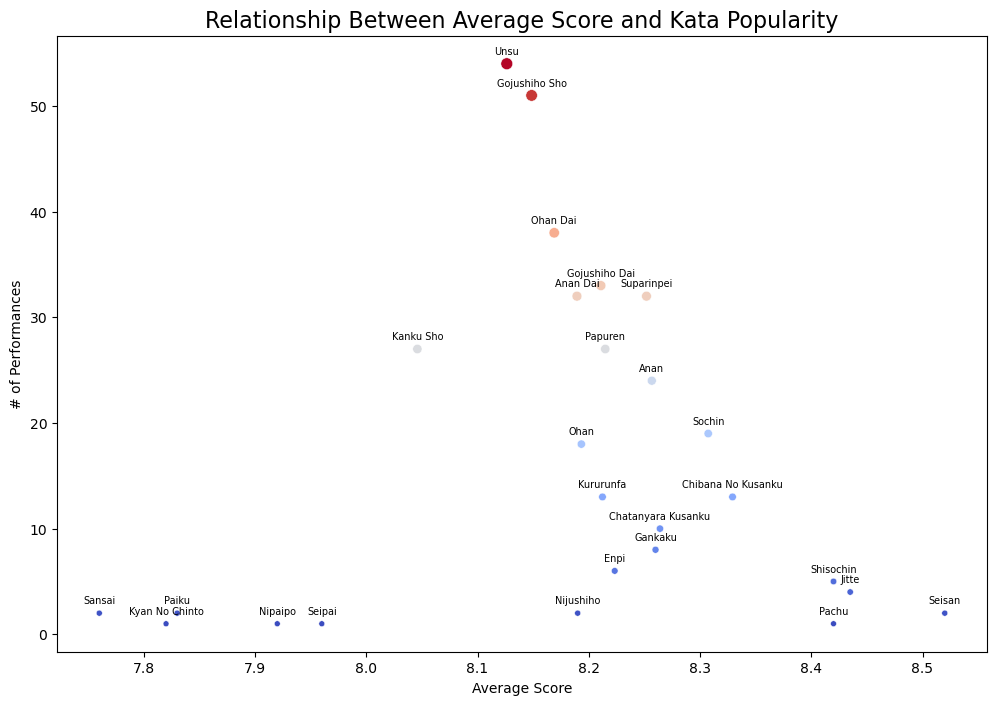

In [49]:
plt.figure(figsize=(12, 8))

# Create the scatterplot with switched axes
sns.scatterplot(data=kata_analysis, x='Avg Score', y='Performances', hue='Performances', palette='coolwarm', size='Performances', legend=False)

# Annotate each point with the kata name
for i, row in kata_analysis.iterrows():
    plt.text(row['Avg Score'], row['Performances'] + 0.7, row['Kata'], fontsize=7, ha='center', va='bottom')

# Add labels and title
plt.xlabel('Average Score')
plt.ylabel('# of Performances')
plt.title('Relationship Between Average Score and Kata Popularity', fontsize = 16)
plt.show()

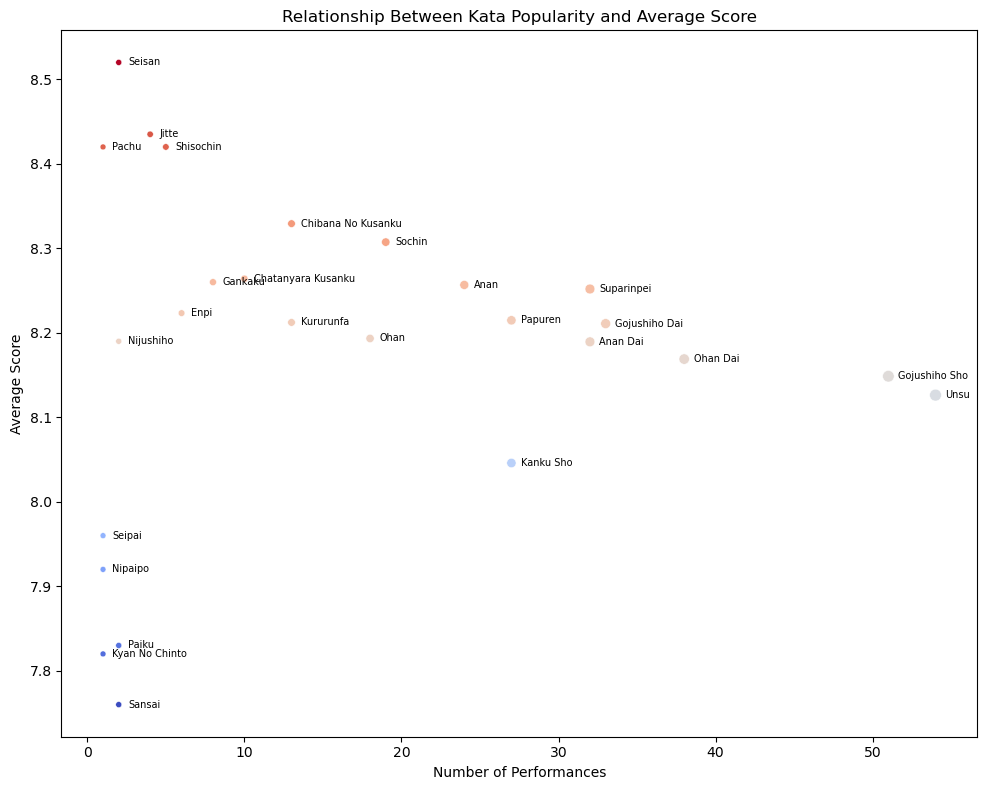

In [50]:
# Plot the scatterplot with switched axes
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=kata_analysis, 
    x='Performances',       # Performances on the x-axis
    y='Avg Score',          # Avg Score on the y-axis
    hue='Avg Score',        # Optional: use Avg Score to color points
    palette='coolwarm', 
    size='Performances',
    legend=False
)

# Add the kata names as annotations
for i, row in kata_analysis.iterrows():
    plt.text(row['Performances'] + .6, row['Avg Score'], row['Kata'], fontsize=7, ha='left', va='center')

# Add labels and title
plt.xlabel('Number of Performances')
plt.ylabel('Average Score')
plt.title('Relationship Between Kata Popularity and Average Score')

plt.tight_layout()
plt.show()

## **Statistical Clusters**

In [53]:
from sklearn.cluster import KMeans

# Select the relevant features for clustering (number of performances and average score)
X = kata_analysis[['Performances', 'Avg Score']]

# Fit KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kata_analysis['KMeans Cluster'] = kmeans.fit_predict(X)

# Display the DataFrame with the clusters
display(kata_analysis[['Kata', 'Performances', 'Avg Score', 'KMeans Cluster']].head())

C:\Users\Gordon Chan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Kata,Performances,Avg Score,KMeans Cluster
25,Nipaipo,1,7.92,0
23,Kyan No Chinto,1,7.82,0
22,Pachu,1,8.42,0
24,Seipai,1,7.96,0
21,Seisan,2,8.52,0


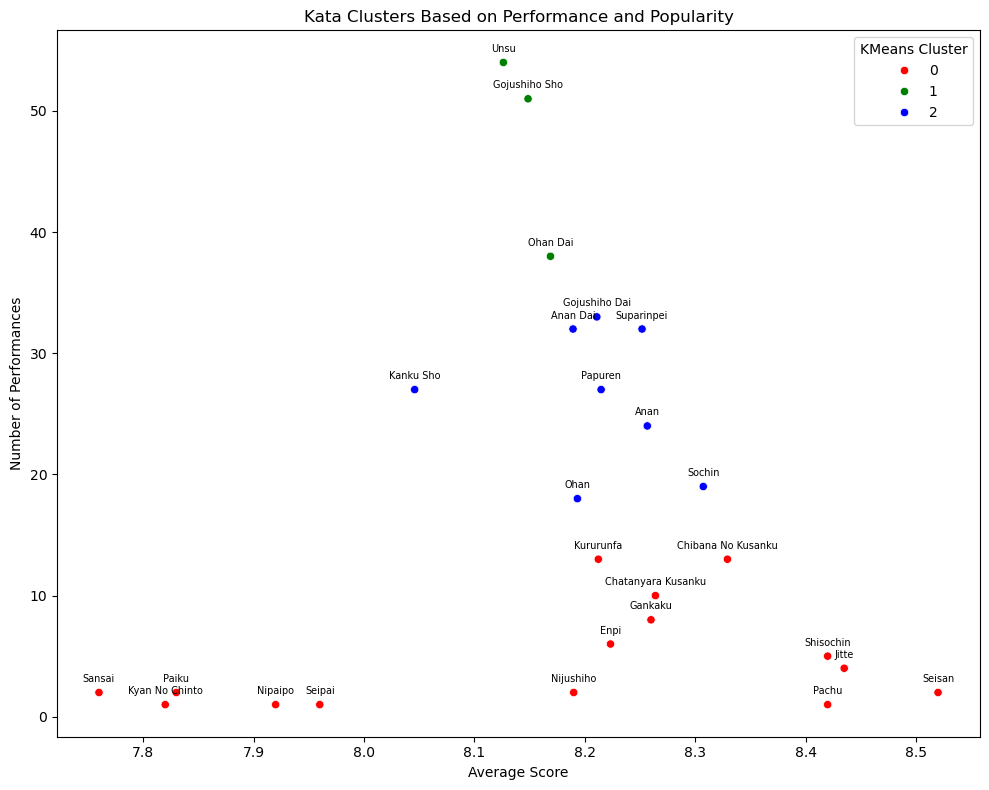

In [54]:
plt.figure(figsize=(10, 8))

# Define a custom color palette for the clusters
cluster_colors = {0: 'red', 1: 'green', 2: 'blue'}  # Assign distinct colors to each cluster

# Scatter plot of kata, colored by their KMeans cluster, with custom colors for each cluster
sns.scatterplot(data=kata_analysis, x='Avg Score', y='Performances', hue='KMeans Cluster', palette=cluster_colors, legend='full')

# Annotate each point with the kata name
for i, row in kata_analysis.iterrows():
    plt.text(row['Avg Score'], row['Performances'] + .7, row['Kata'], fontsize=7, ha='center', va='bottom')

# Add labels and title
plt.xlabel('Average Score')
plt.ylabel('Number of Performances')
plt.title('Kata Clusters Based on Performance and Popularity')

# Tight layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

#### Further Reading
https://www.wkf.net/pdf/WKF_Kata_Competition_Rules_2024.pdf
https://assets.contentstack.io/v3/assets/blteb7d012fc7ebef7f/blt948731043d7aeb6c/64887a8bea50bc52adbe8b23/2023-03-14_Official_Kata_List.PDF